### Error analysis by item
- Simulation test for error concentration


In [1]:
import pickle, json
import pandas as pd 
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from sklearn.metrics import silhouette_score

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr

In [ ]:
# get the selected survey items
df_avg = pd.read_csv("./data/wvs7_country_avg.csv").set_index('Country')
items = list(df_avg.columns) # select the same items for the following dataframes
all_countries = list(df_avg.index)
df_avg.shape

(66, 117)

In [ ]:
df_wvs = pd.read_csv("./data/wvs7_scaled.csv")[['Country'] + items].set_index('Country')
df_wvs.shape

(97220, 117)

In [ ]:
df_c2q = pd.read_csv('./data/Maps - code2question.csv')
df_c2q['question'] = df_c2q['s_category'] + ': ' + df_c2q['q_content']

In [ ]:
# LLM country representation
# make sure rows/countries and columns/items have consistent orders
df_gpt = pd.read_csv("./data/llm/gpt_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_claude = pd.read_csv("./data/claude_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_deepseek = pd.read_csv("./data/deepseek_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]

df_gpt.shape, df_claude.shape, df_deepseek.shape

((66, 117), (66, 117), (66, 117))

In [ ]:
# LLM country representation
df_llm = df_gpt # df_gpt, df_claude, df_deepseek
llm_name = "GPT" # GPT, Claude, DeepSeek

with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_error = pickle.load(f)

### Visualize misrepresentation by item

In [7]:
df_error_byItem = pd.DataFrame({
    'misrepresentation': df_error.abs().sum(axis=0),
    'over_estimate': df_error.apply(lambda row: row[row > 0].sum(), axis=0),
    'under_estimate': df_error.apply(lambda row: row[row < 0].sum(), axis=0),
}, index=items)

df_error_byItem.head().round(3)

,misrepresentation,over_estimate,under_estimate
A001,0,0,0
A002,1,1,0
A003,0,0,0
A004,2,2,0
A005,2,0,-2


In [ ]:
def visualize_double_connect(df_error_byItem,topn=10):
    c2q = df_c2q.set_index('code')['question']
    over_color  = '#d62728'
    under_color = '#1f77b4'
    w = 0.6
    GAP = 1  # blank rows between sections

    # over: sorted ascending so largest appears at top (highest y)
    df_over  = df_error_byItem.nlargest(topn, 'over_estimate').sort_values('over_estimate', ascending=True)
    # under: sorted ascending so most negative appears at bottom (lowest y)
    df_under = df_error_byItem.nsmallest(topn, 'under_estimate').sort_values('under_estimate', ascending=True)

    n_over  = len(df_over)
    n_under = len(df_under)

    # y positions: under section at bottom (0 … n_under-1), over section above gap
    y_under = np.arange(n_under)
    y_over  = np.arange(n_under + GAP, n_under + GAP + n_over)

    fig, ax = plt.subplots(figsize=(14, topn)) # 20 for Claude

    # over-estimated bars (right of 0)
    ax.barh(y_over,  df_over['over_estimate'],        height=w, color=over_color,  linewidth=0,
            label='over-estimated')
    # under-estimated bars (also right of 0, showing absolute values)
    ax.barh(y_under, df_under['under_estimate'], height=w, color=under_color, linewidth=0,
            label='under-estimated')

    # separator line between sections
    sep_y = n_under + GAP / 2
    ax.axhline(sep_y, color='#888888', linewidth=1, linestyle='--')

    # connector lines for items appearing in both lists
    over_codes  = set(df_over.index)
    under_codes = set(df_under.index)
    shared = over_codes & under_codes
    over_pos  = {code: y for code, y in zip(df_over.index,  y_over)}
    under_pos = {code: y for code, y in zip(df_under.index, y_under)}
    for code in shared:
        ax.plot([0, 0], [under_pos[code], over_pos[code]],
                color='gray', lw=1, linestyle=':', zorder=1)

    ax.axvline(0, color='#333333', linewidth=0.8)

    # y-tick labels for both sections
    all_yticks = list(y_under) + list(y_over)
    all_labels = (
        [f"{code} ||| {c2q.get(code, code)}" for code in df_under.index] +
        [f"{code} ||| {c2q.get(code, code)}" for code in df_over.index]
    )
    ax.set_yticks(all_yticks)
    ax.set_yticklabels(all_labels, fontsize=18)
    ax.tick_params(axis='y', left=True, right=False, labelleft=True, labelright=False, labelsize=17)
    ax.tick_params(axis='x', labelsize=17)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: int(abs(v))))
    x_right = df_over['over_estimate'].max() * 1.05
    x_left  = df_under['under_estimate'].min() * 1.05
    ax.set_xlim(x_left, x_right)
    ax.set_xlabel('Number of countries', fontsize=22)
    ax.set_title(llm_name + ': Top-'+str(topn)+' over- and under-estimated items', fontsize=25, fontweight='bold')
    ax.legend(framealpha=0.9, loc='upper left', fontsize=20)
    ax.xaxis.grid(True, linewidth=0.5, color='#e0e0e0', linestyle='-')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    # plt.subplots_adjust(left=0.5)
#     fig.savefig("./supfig/"+llm_name+"_topn_items.pdf", dpi=300, bbox_inches="tight")
    
    plt.show()

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_51291/621809361.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


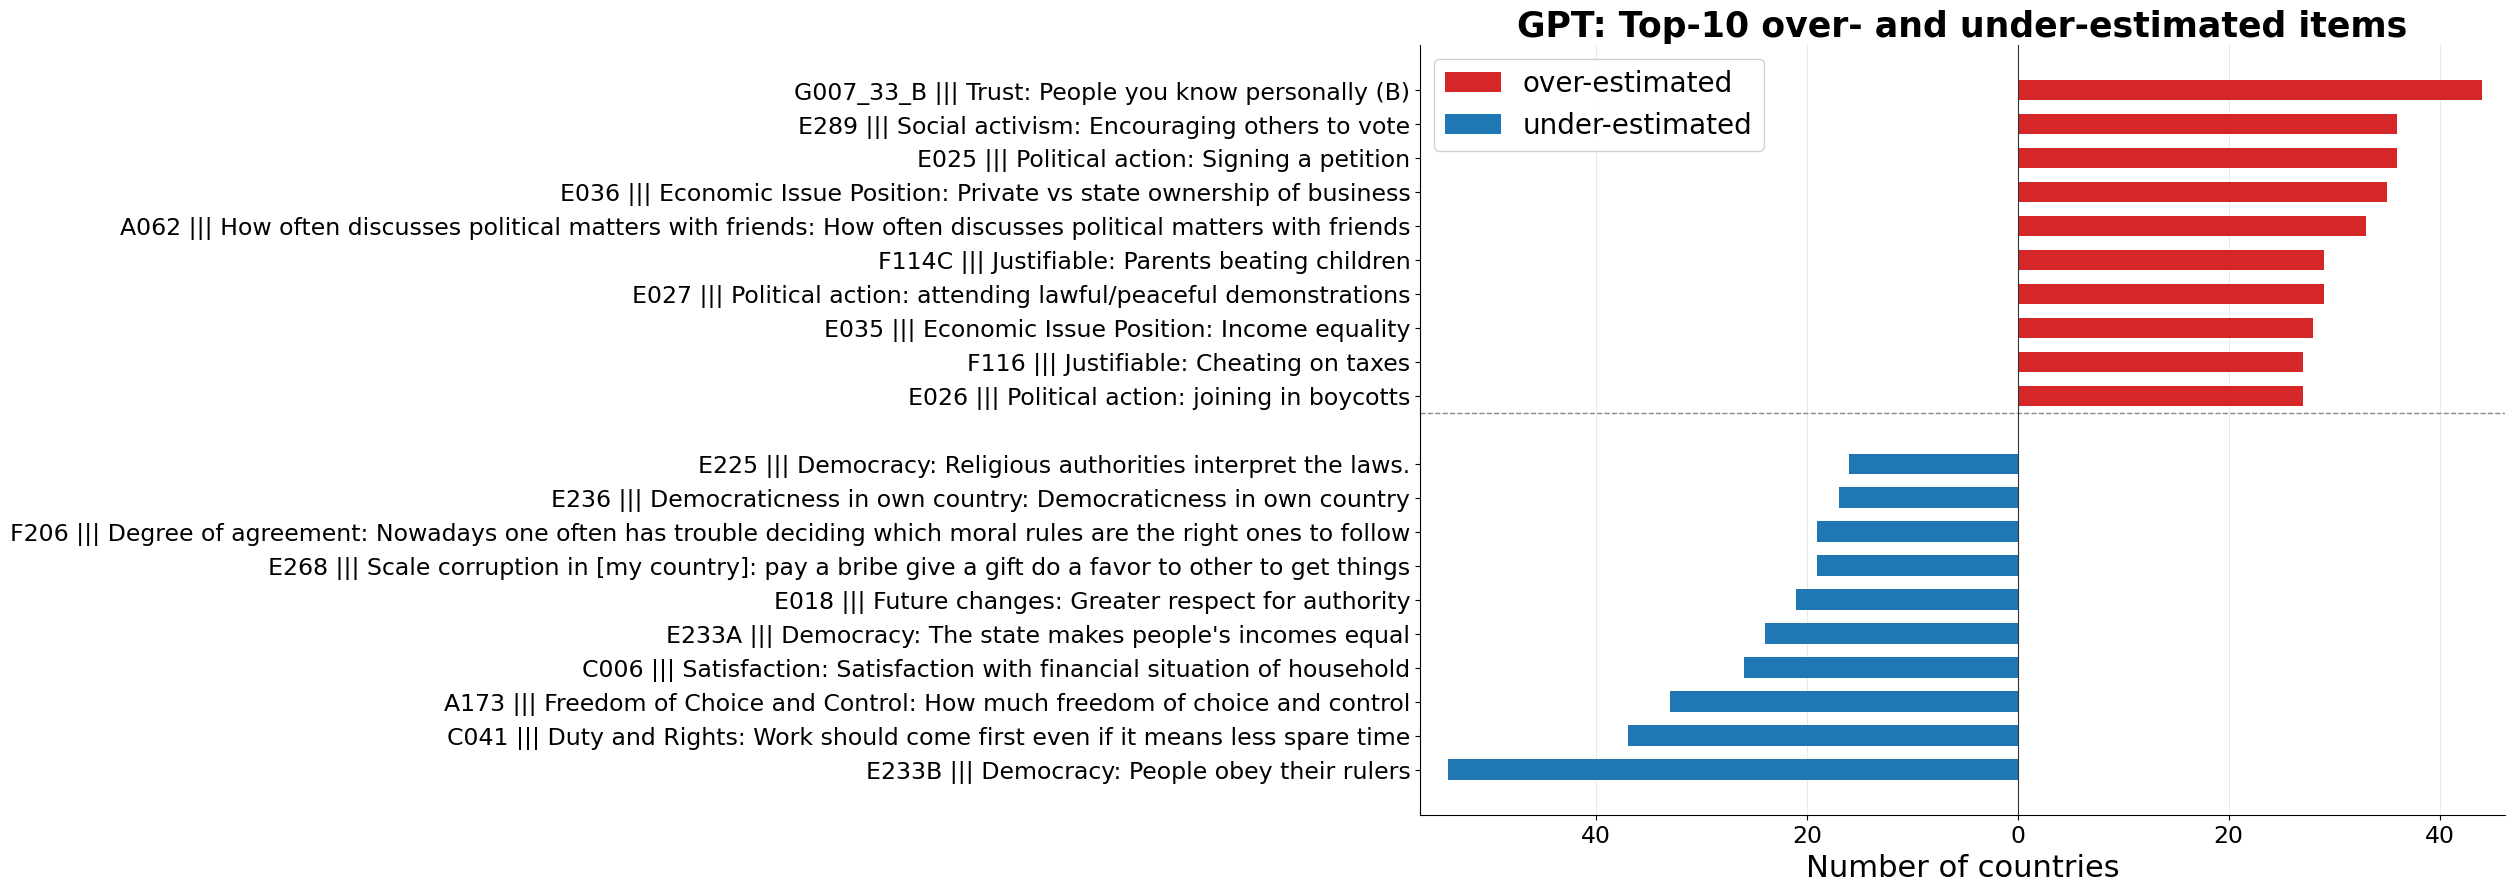

In [12]:
visualize_double_connect(df_error_byItem,10)

In [ ]:
def visualize_item_misrepresentation(df_error_byItem):
    # vertical visualization (x/y axes flipped)
    df_plot = df_error_byItem.copy()
    df_plot = df_plot.sort_values('over_estimate')

    n = len(df_plot)
    y = np.arange(n)
    w = 0.6

    over_color  = '#d62728'  # red  — over-estimate (positive bias)
    under_color = '#1f77b4'  # blue — under-estimate (negative bias)

    fig, ax = plt.subplots(figsize=(6, 24))

    ax.barh(y, df_plot['over_estimate'],  height=w, color=over_color,  label='Over-estimation: %d' % int(df_plot['over_estimate'].mean(axis=0).round()),  linewidth=0)
    ax.barh(y, df_plot['under_estimate'], height=w, color=under_color, label='Under-estimation: %d' % abs(int(df_plot['under_estimate'].mean(axis=0).round())), linewidth=0)

    ax.axvline(0, color='#333333', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_ylim(-0.5, n-0.5)
    c2q = df_c2q.set_index('code')['question']
    y_labels = [f"{code} ||| {c2q.get(code, code)}" for code in df_plot.index]
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.tick_params(axis='y', left=True, right=False, labelleft=True, labelright=False)
    ax.tick_params(axis='x', labelsize=15)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: int(abs(v))))
    ax.set_xlabel('Number of countries', fontsize=15)
    ax.set_title(llm_name+': over- and under-estimated items', 
                fontsize=20, fontweight="bold")
    ax.legend(framealpha=0.9, loc='upper left', fontsize=10)
    ax.xaxis.grid(True, linewidth=0.5, color='#e0e0e0', linestyle='-')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    # plt.savefig('./supfig/'+llm_name+'_all_items.pdf', dpi=300, bbox_inches='tight')
    plt.show()


/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_51291/505183480.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


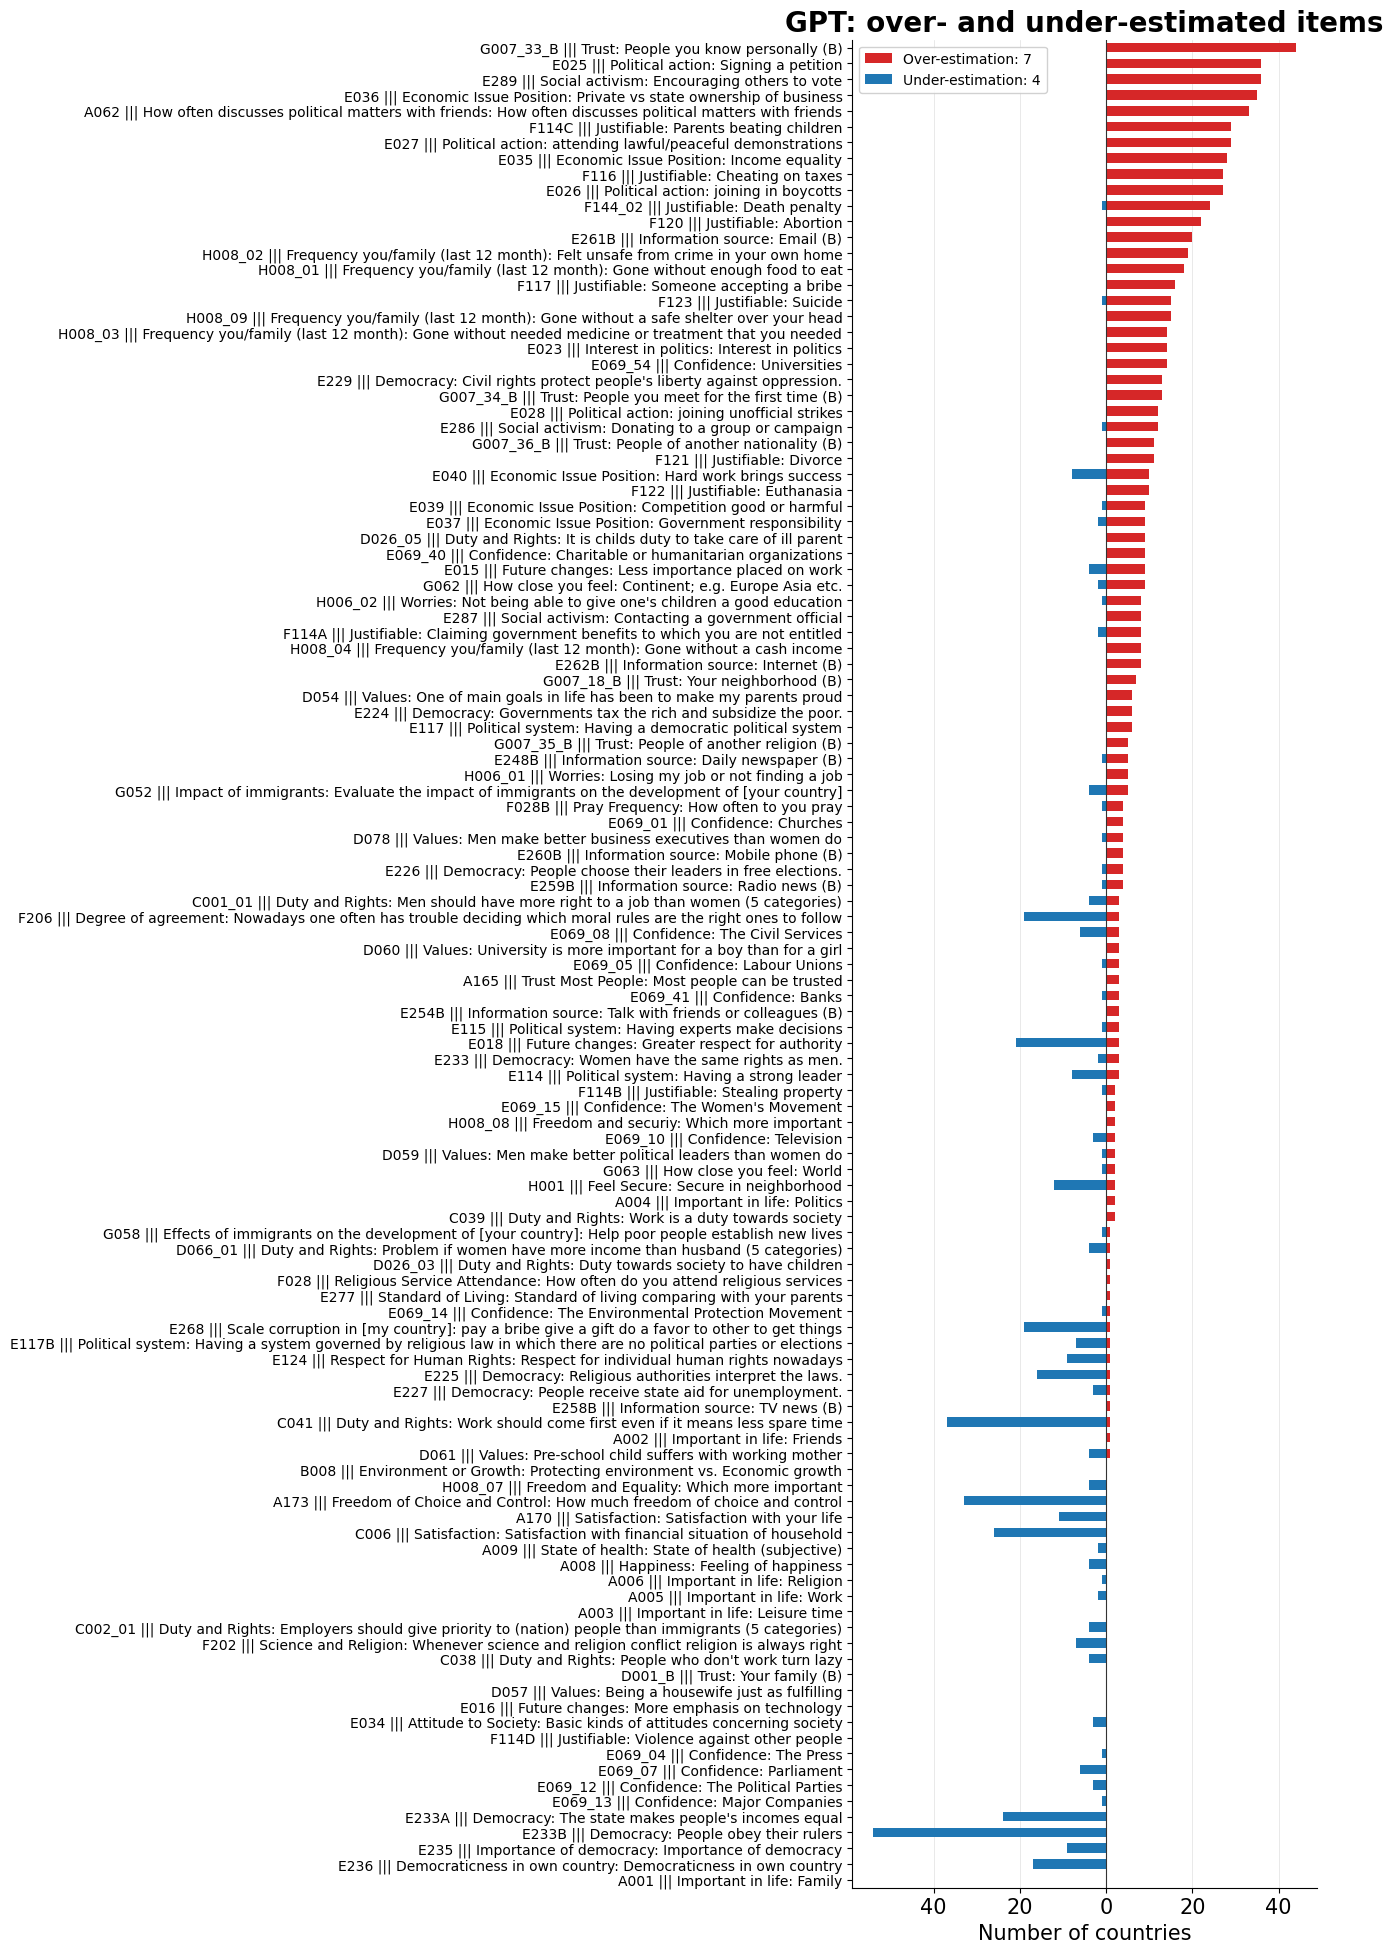

In [14]:
visualize_item_misrepresentation(df_error_byItem)

In [26]:
# vertical visualization (x/y axes flipped)
def visualize_item_underrepresentation(df_error_byItem):
    df_plot = df_error_byItem.copy()
    df_plot = df_plot.sort_values('under_estimate', ascending=False)

    n = len(df_plot)
    y = np.arange(n)
    w = 0.6

    over_color  = '#d62728'  # red  — over-estimate (positive bias)
    under_color = '#1f77b4'  # blue — under-estimate (negative bias)

    fig, ax = plt.subplots(figsize=(6, 24))

    # ax.barh(y, df_plot['over_estimate'],  height=w, color=over_color,  label='Average over-estimation: %d' % int(df_plot['over_estimate'].mean(axis=0).round(3)),  linewidth=0)
    ax.barh(y, df_plot['under_estimate'].abs(), height=w, color=under_color, label='Average under-estimation: %d' % int(df_plot['under_estimate'].abs().mean(axis=0).round()), linewidth=0)

    ax.axvline(0, color='#333333', linewidth=0.8)
    ax.set_yticks(y)
    c2q = df_c2q.set_index('code')['question']
    y_labels = [f"{code} ||| {c2q.get(code, code)}" for code in df_plot.index]
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.tick_params(axis='y', left=True, right=False, labelleft=True, labelright=False, size=10, labelsize=10)
    ax.set_xlabel('\nNumber of under-estimated countries', fontsize=14)
    ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.xaxis.set_label_position('top')
    ax.set_title(llm_name+': under-estimated items', fontsize=20, fontweight="bold")
    ax.legend(framealpha=0.9, loc='upper left', fontsize=12,
            bbox_to_anchor=(0, 1), bbox_transform=ax.transAxes)
    ax.xaxis.grid(True, linewidth=0.5, color='#e0e0e0', linestyle='-')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_85130/1384268138.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


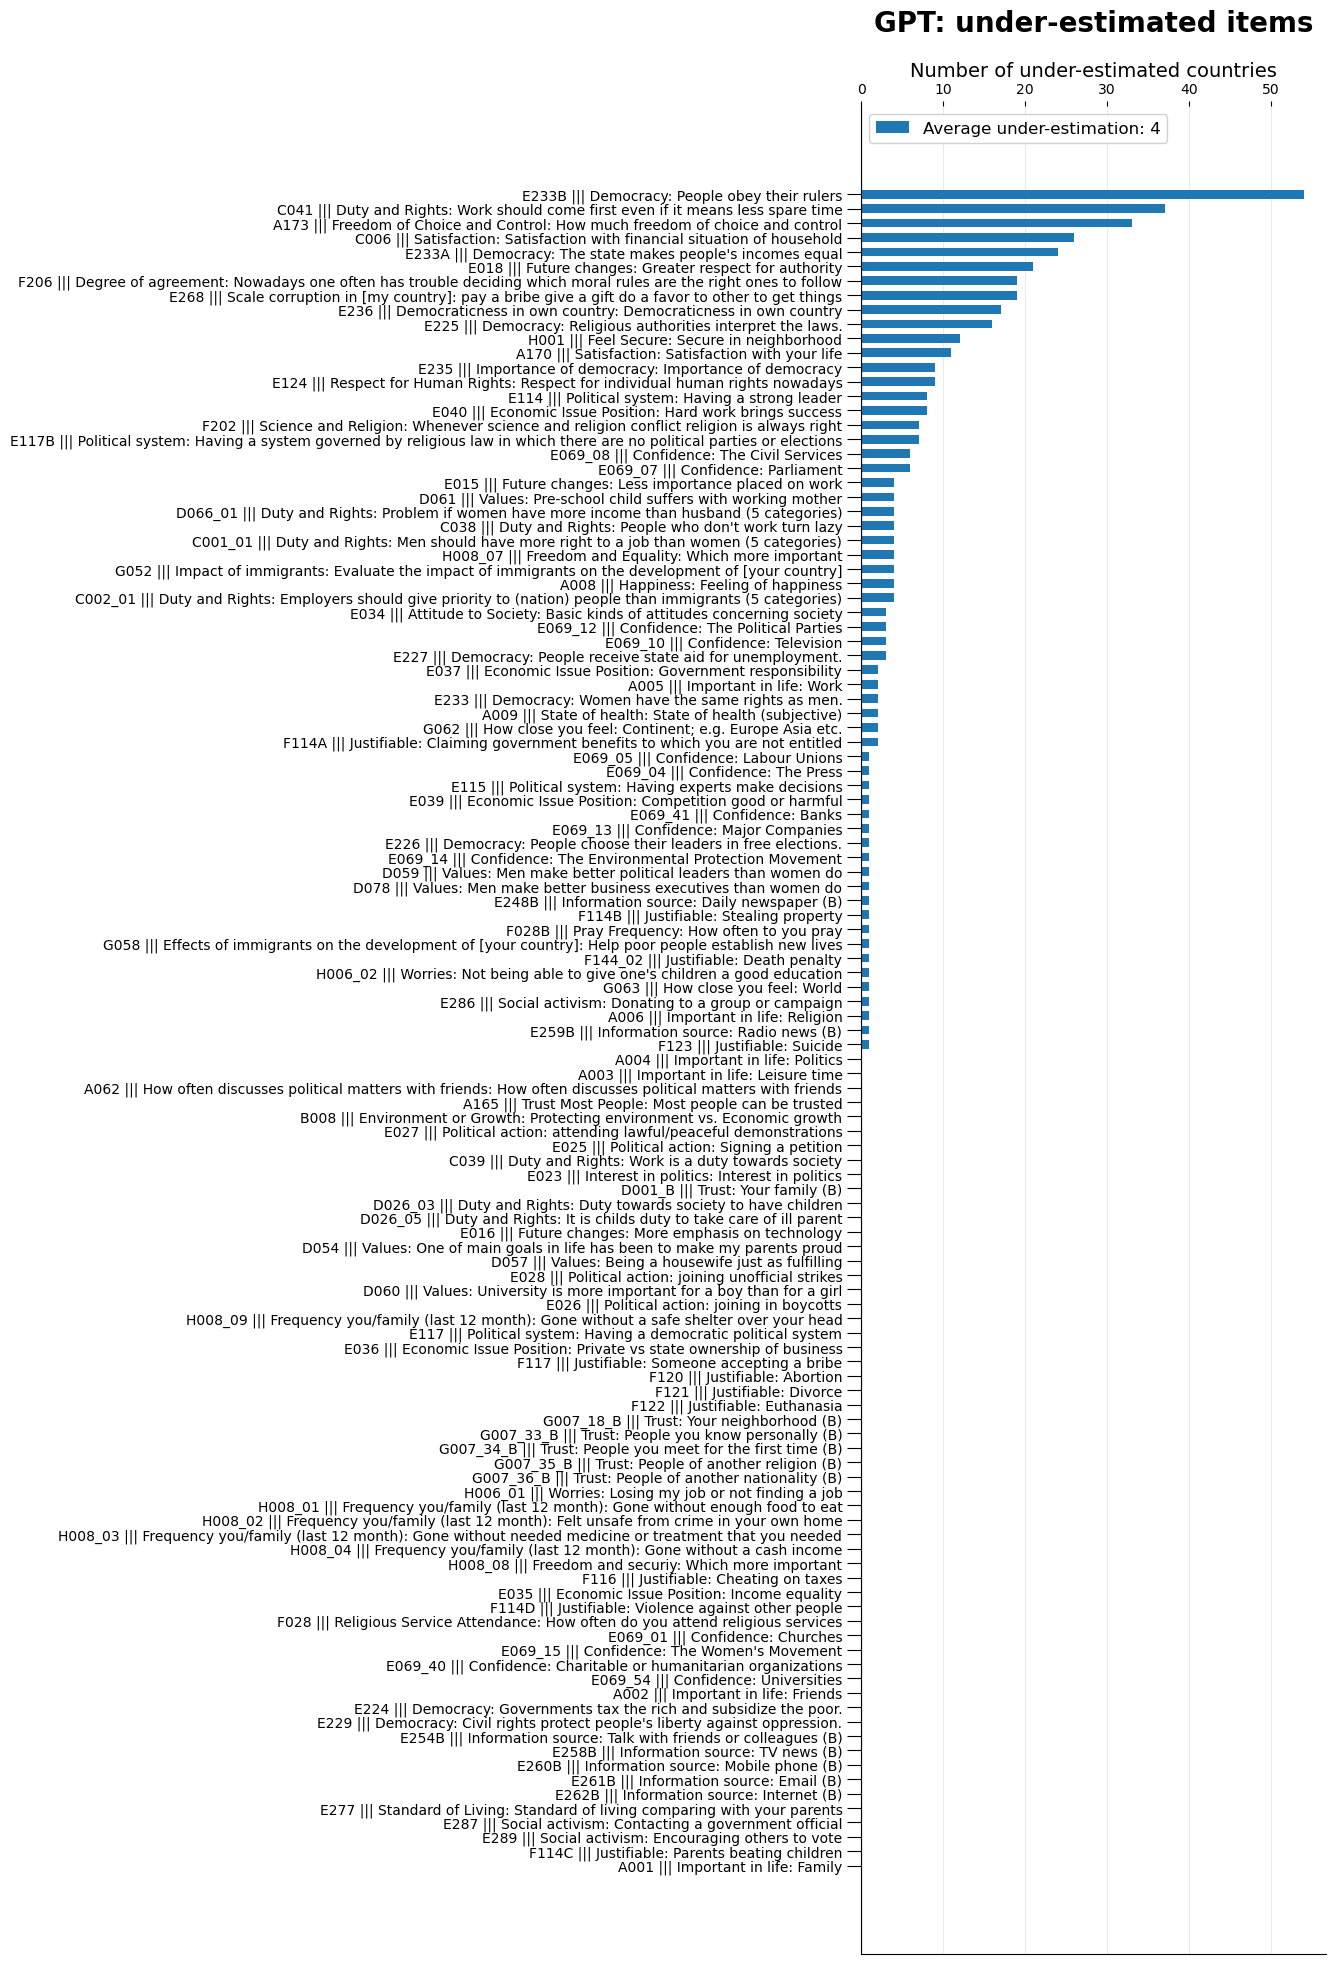

In [27]:
visualize_item_underrepresentation(df_error_byItem)

### Replicate results for Claude

In [ ]:
# LLM country representation
df_llm = df_claude 
llm_name = "Claude" 

with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_error = pickle.load(f)
    
df_error_byItem = pd.DataFrame({
    'misrepresentation': df_error.abs().sum(axis=0),
    'over_estimate': df_error.apply(lambda row: row[row > 0].sum(), axis=0),
    'under_estimate': df_error.apply(lambda row: row[row < 0].sum(), axis=0),
}, index=items)

df_error_byItem.head().round(3)

,misrepresentation,over_estimate,under_estimate
A001,0,0,0
A002,4,4,0
A003,9,0,-9
A004,4,1,-3
A005,19,0,-19


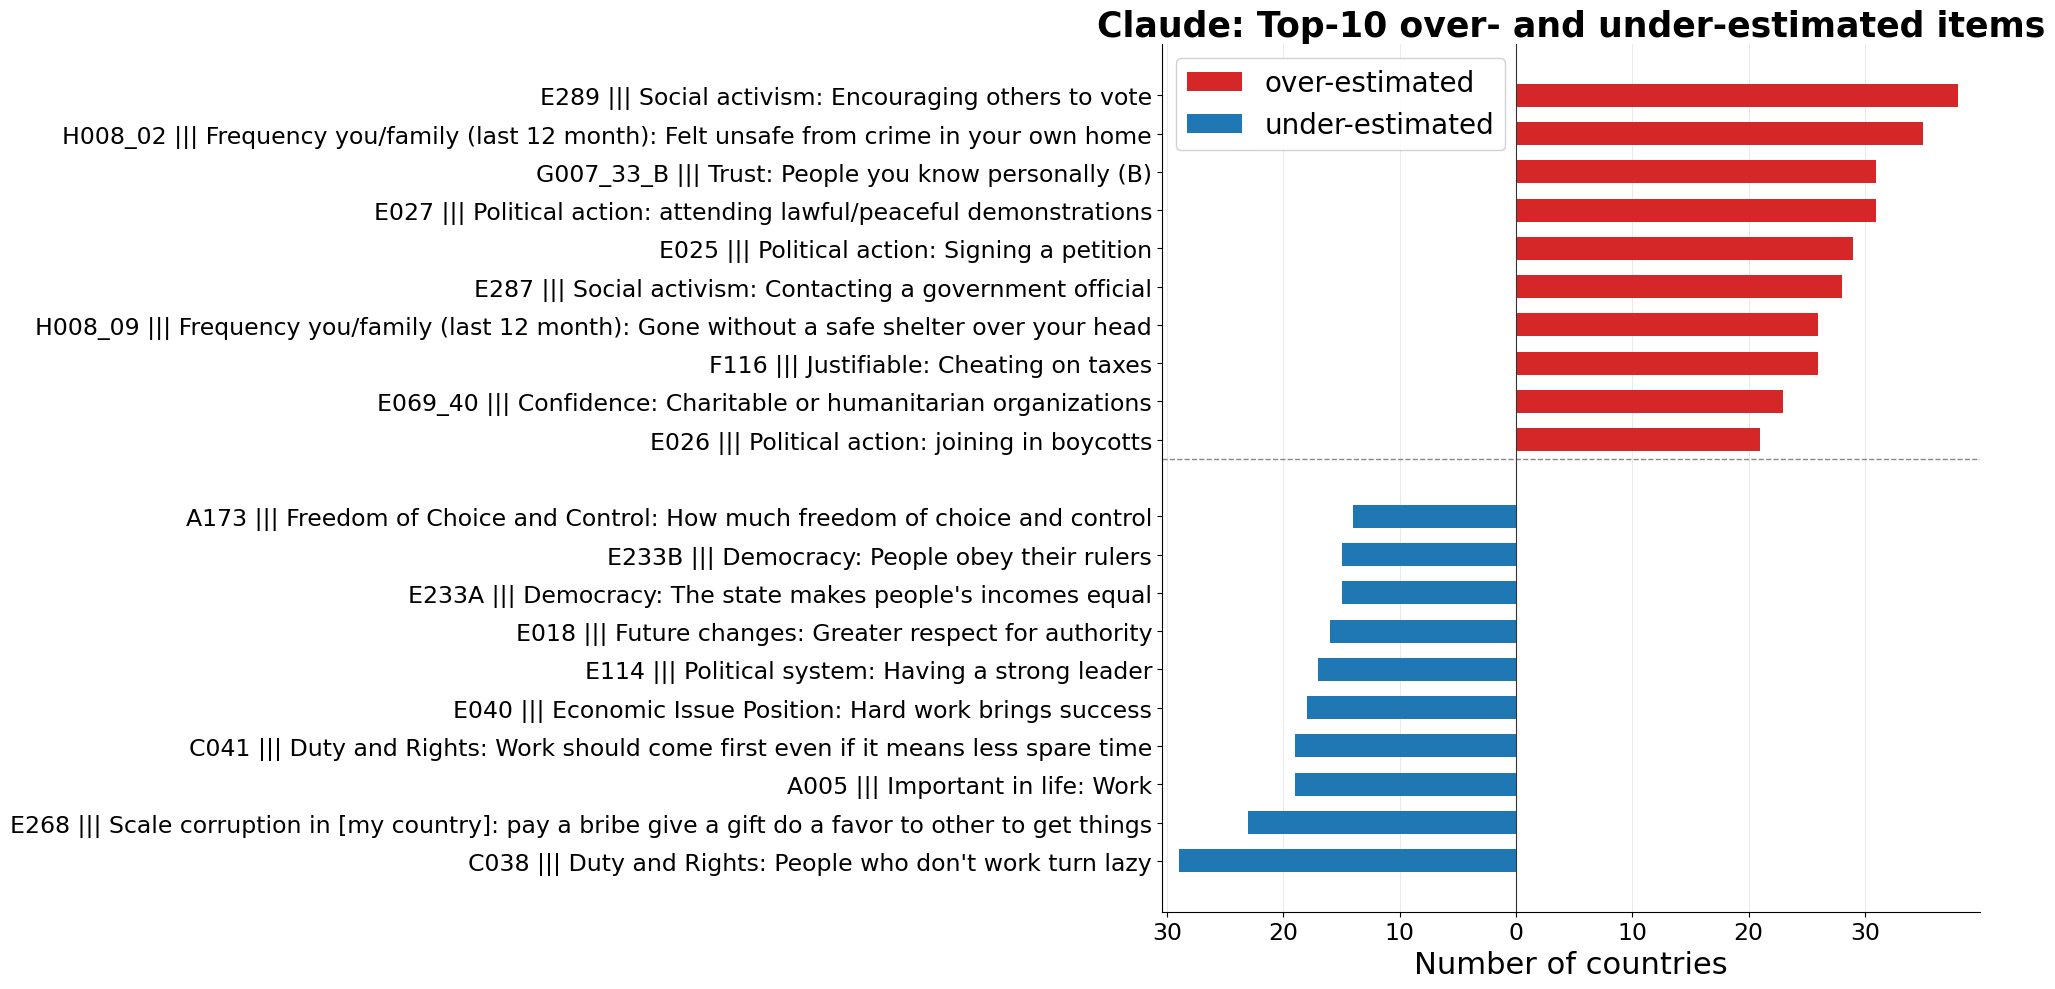

In [17]:
visualize_double_connect(df_error_byItem,10)

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_51291/505183480.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


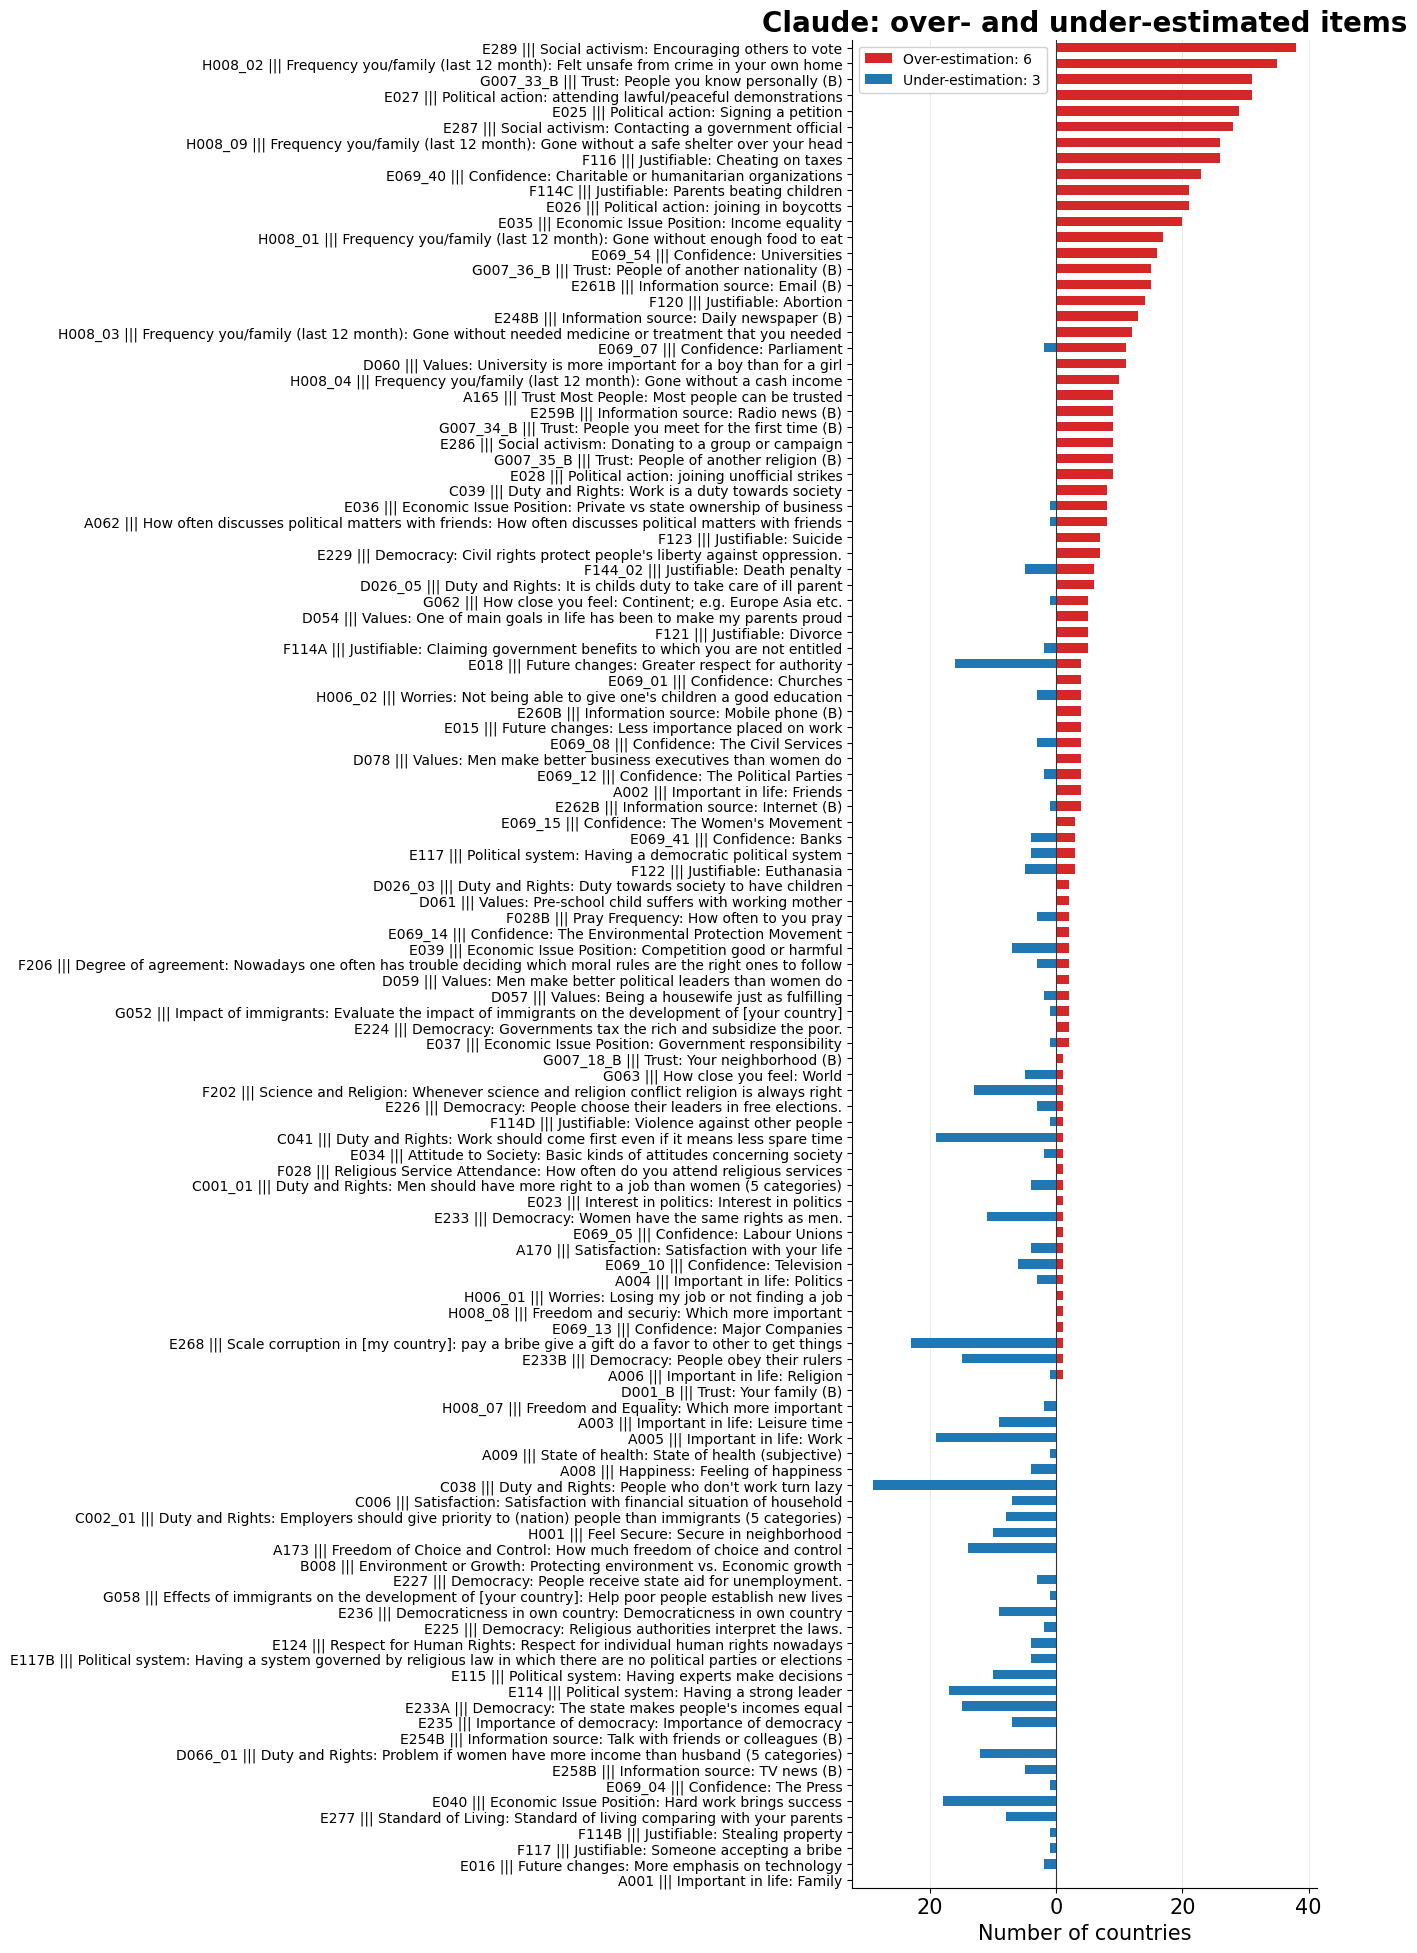

In [17]:
visualize_item_misrepresentation(df_error_byItem)

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_85130/1384268138.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


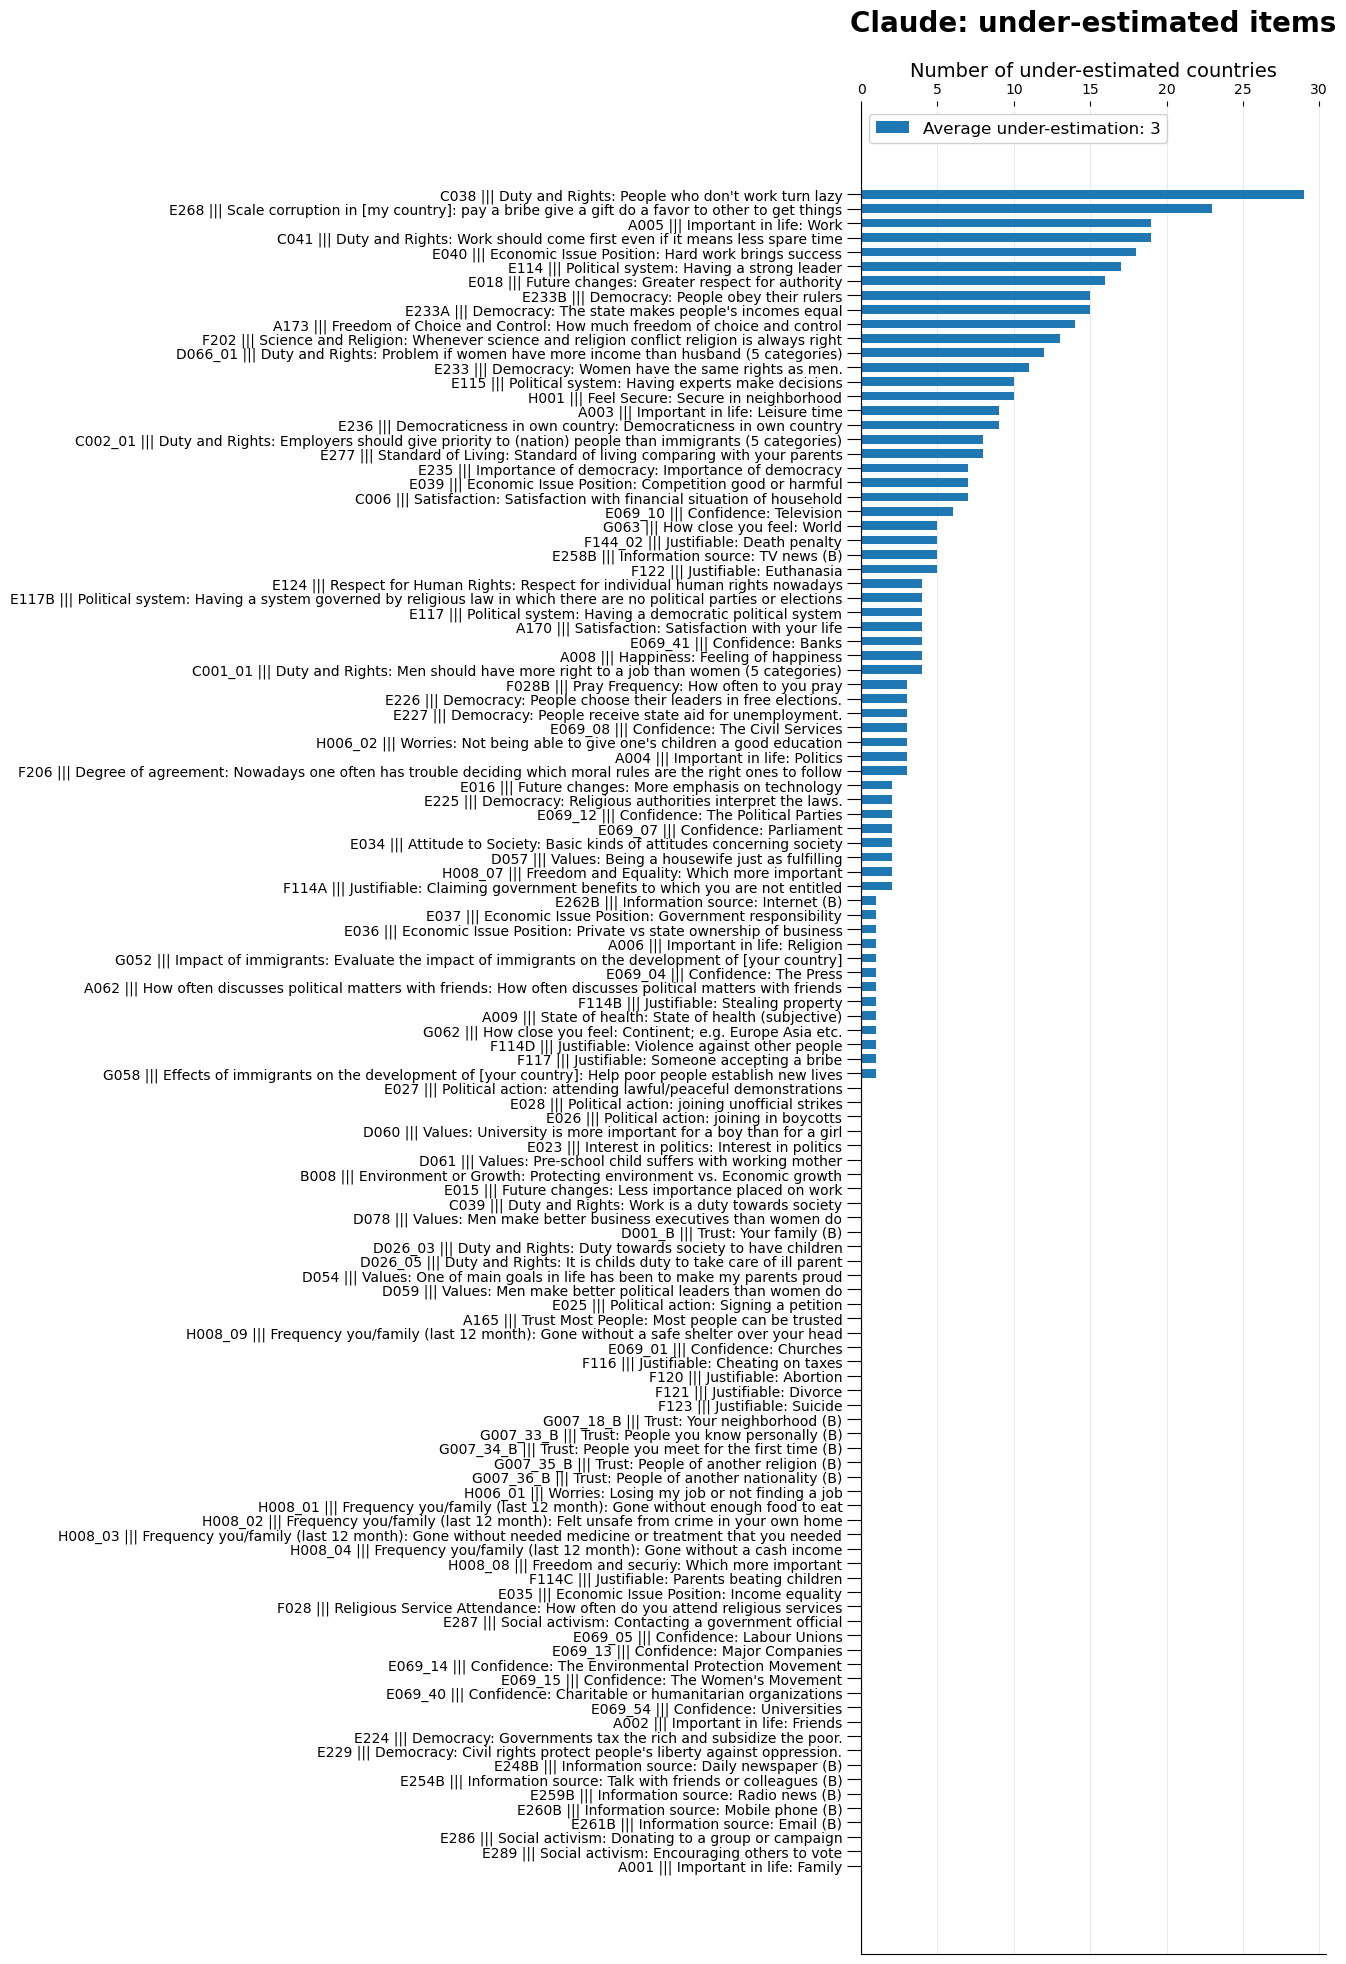

In [48]:
visualize_item_underrepresentation(df_error_byItem)

### Replicate results for DeepSeek

In [ ]:
# LLM country representation
df_llm = df_deepseek
llm_name = "DeepSeek" 

with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_error = pickle.load(f)
    
df_error_byItem = pd.DataFrame({
    'misrepresentation': df_error.abs().sum(axis=0),
    'over_estimate': df_error.apply(lambda row: row[row > 0].sum(), axis=0),
    'under_estimate': df_error.apply(lambda row: row[row < 0].sum(), axis=0),
}, index=items)

df_error_byItem.head().round(3)

,misrepresentation,over_estimate,under_estimate
A001,1,0,-1
A002,1,1,0
A003,9,0,-9
A004,3,0,-3
A005,13,0,-13


/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_51291/621809361.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


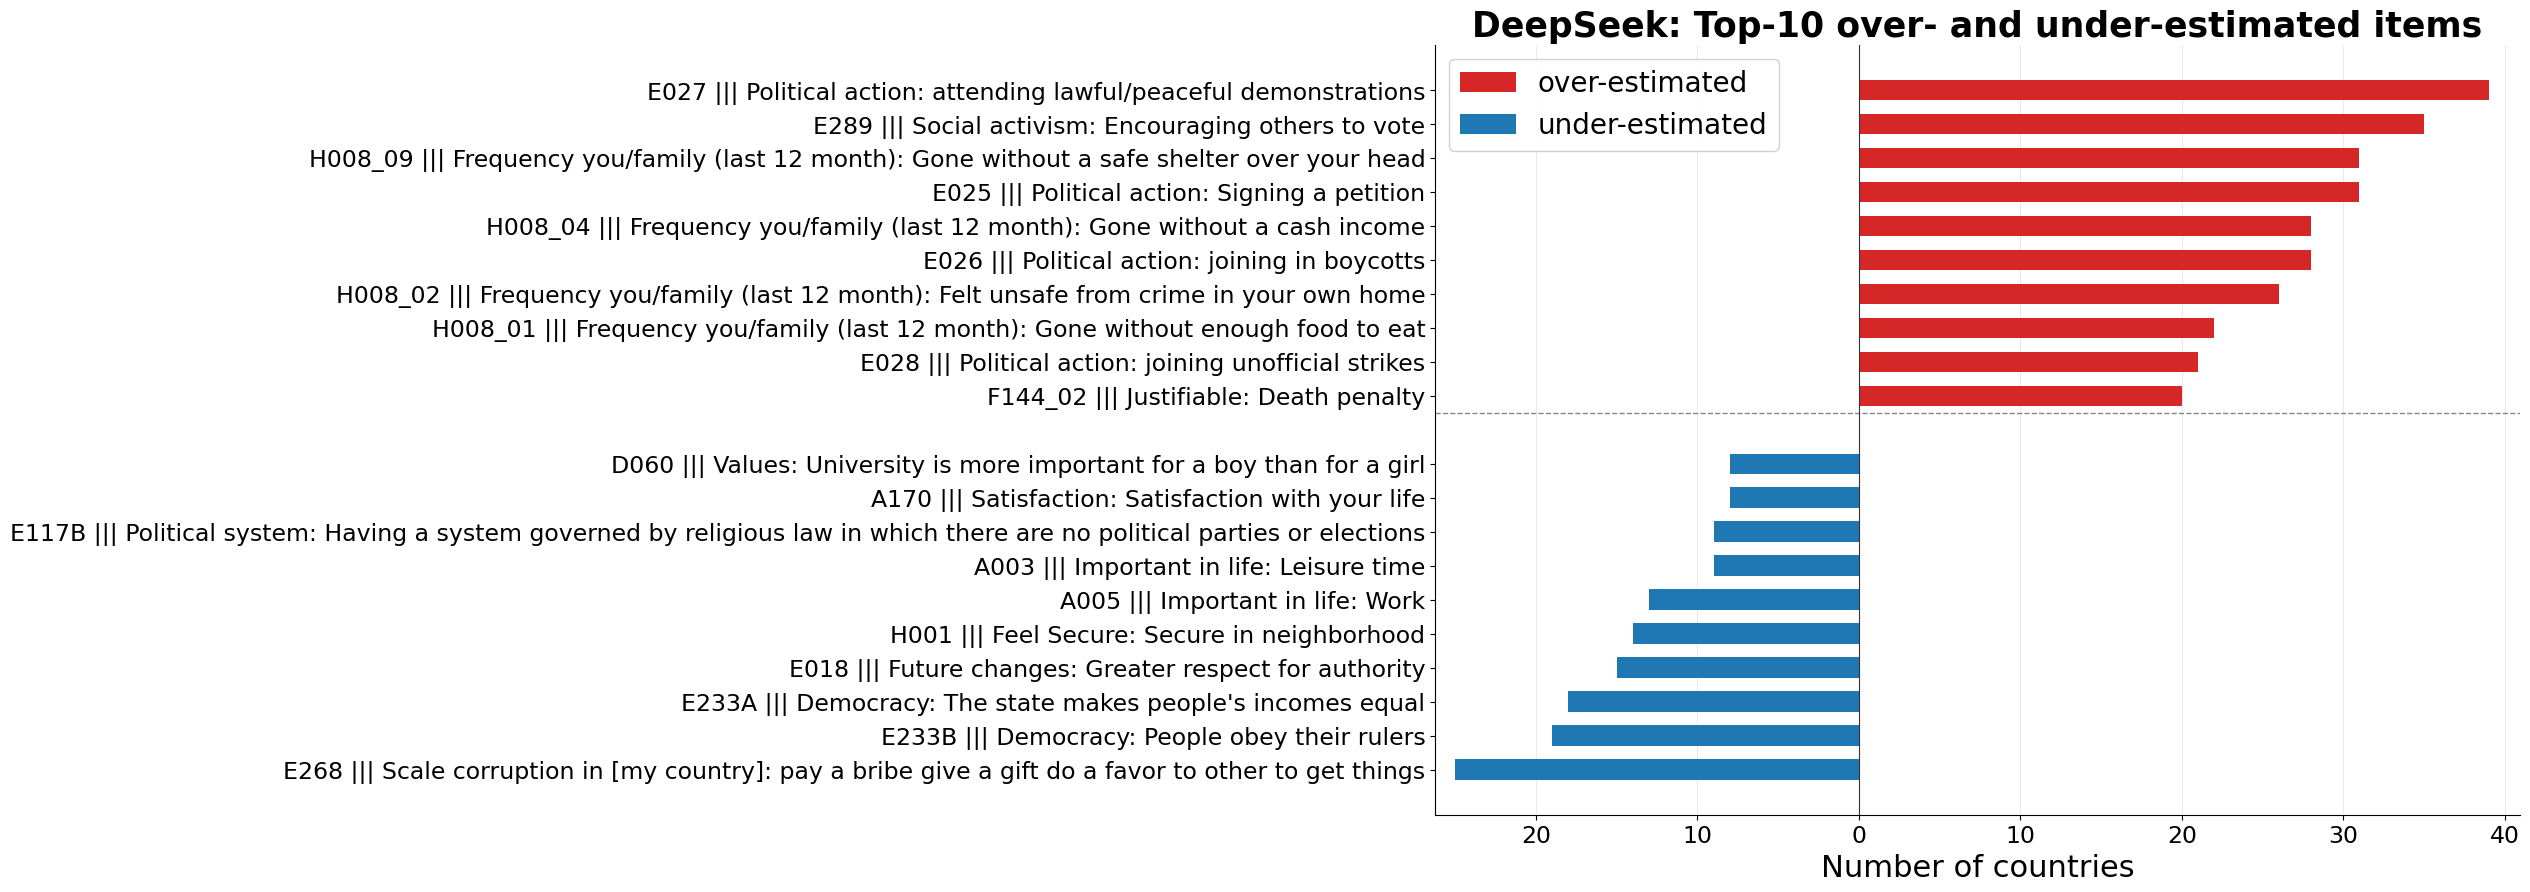

In [19]:
visualize_double_connect(df_error_byItem,10)

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_51291/505183480.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


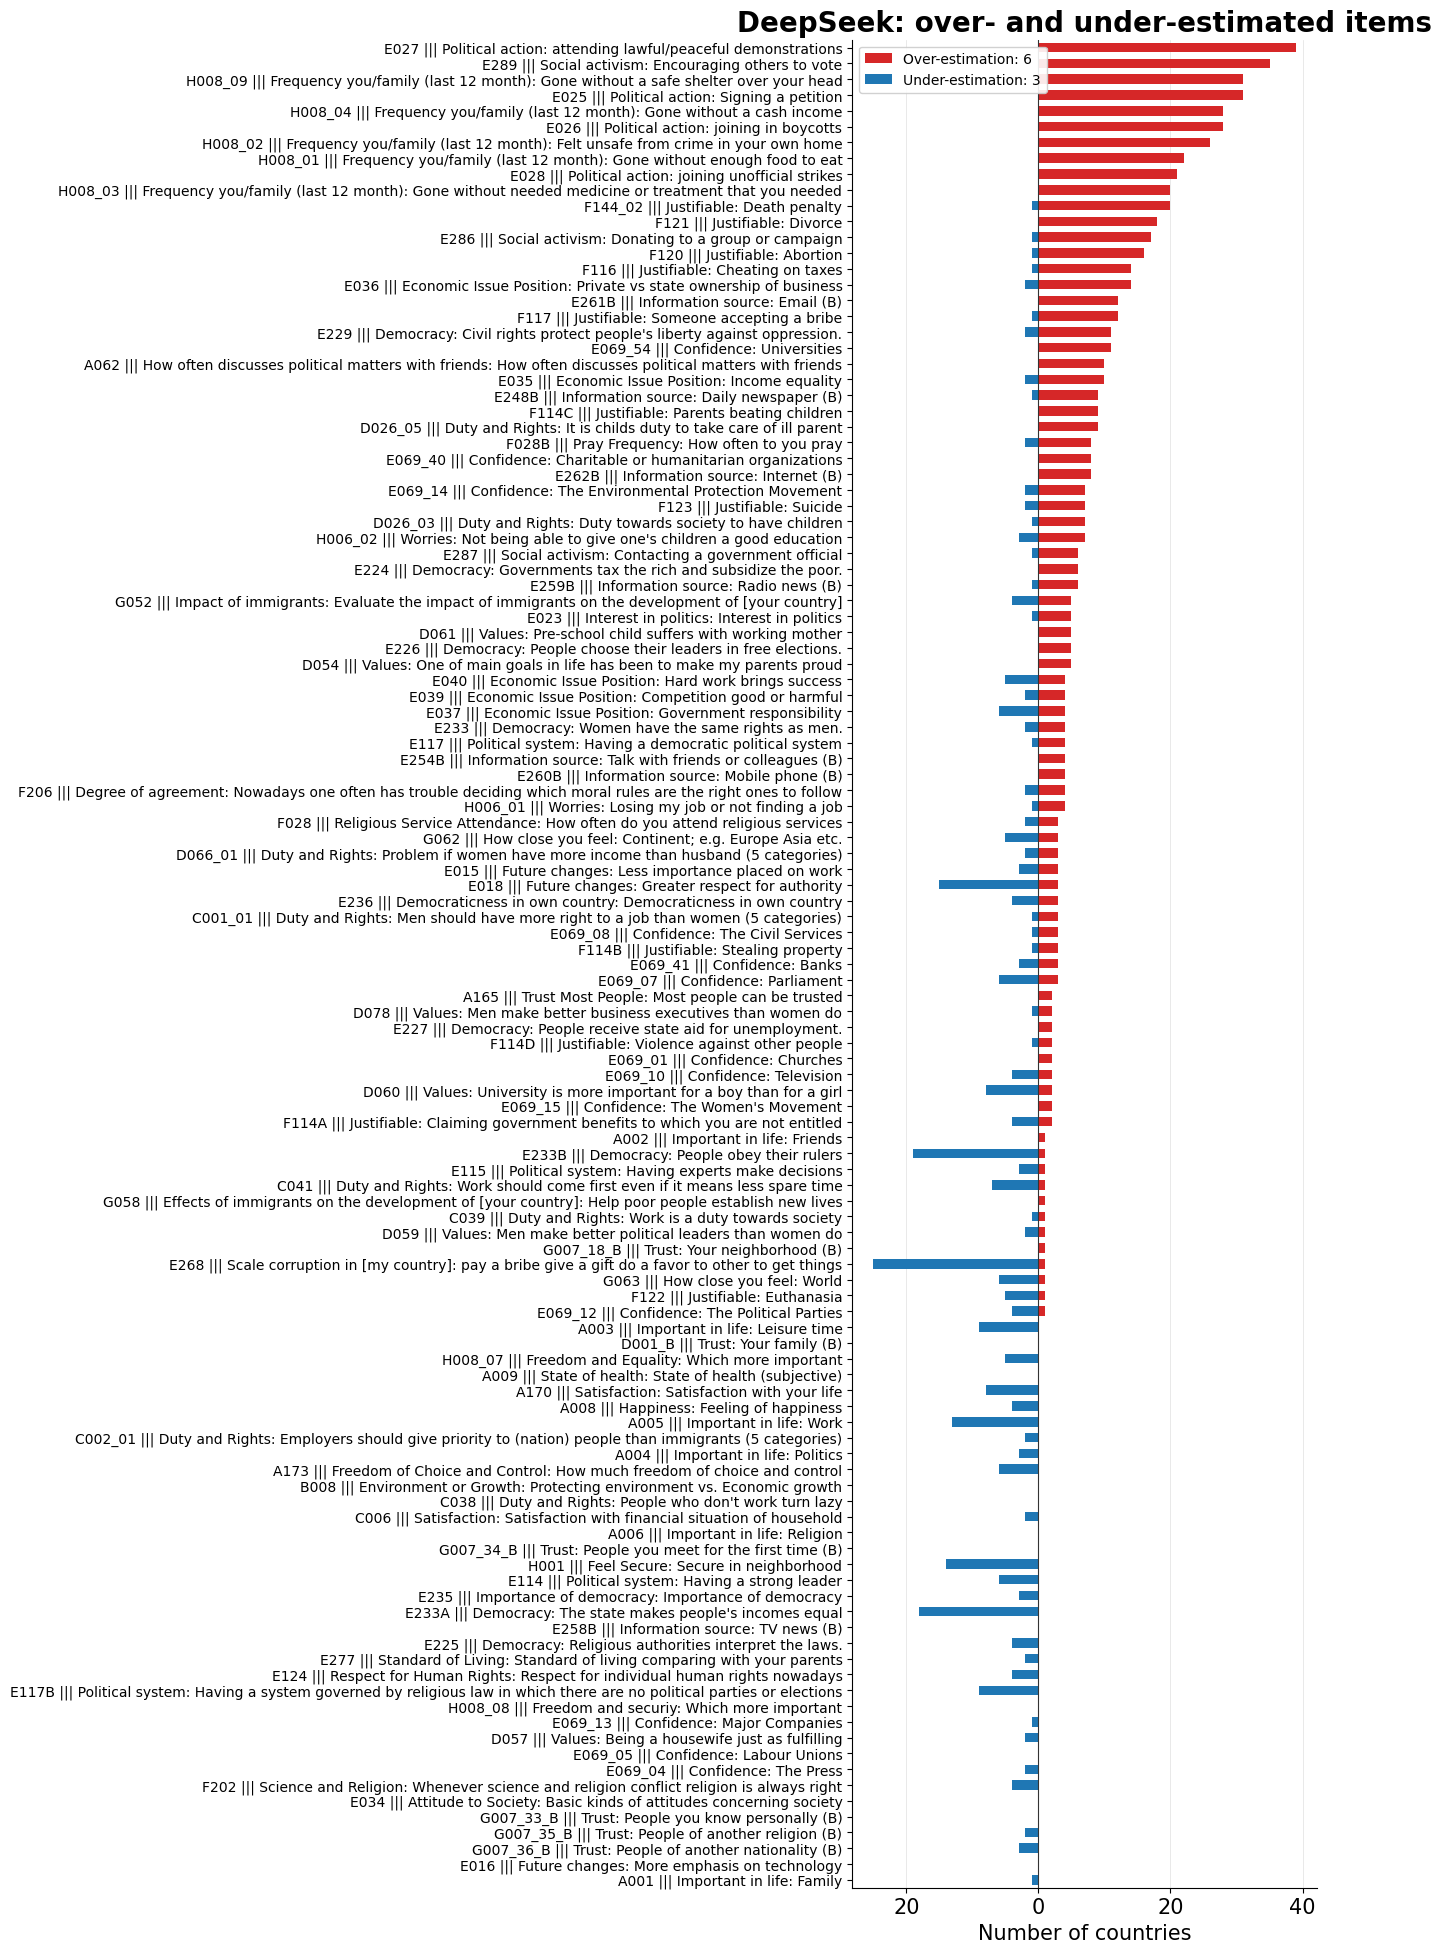

In [20]:
visualize_item_misrepresentation(df_error_byItem)

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_85130/1384268138.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


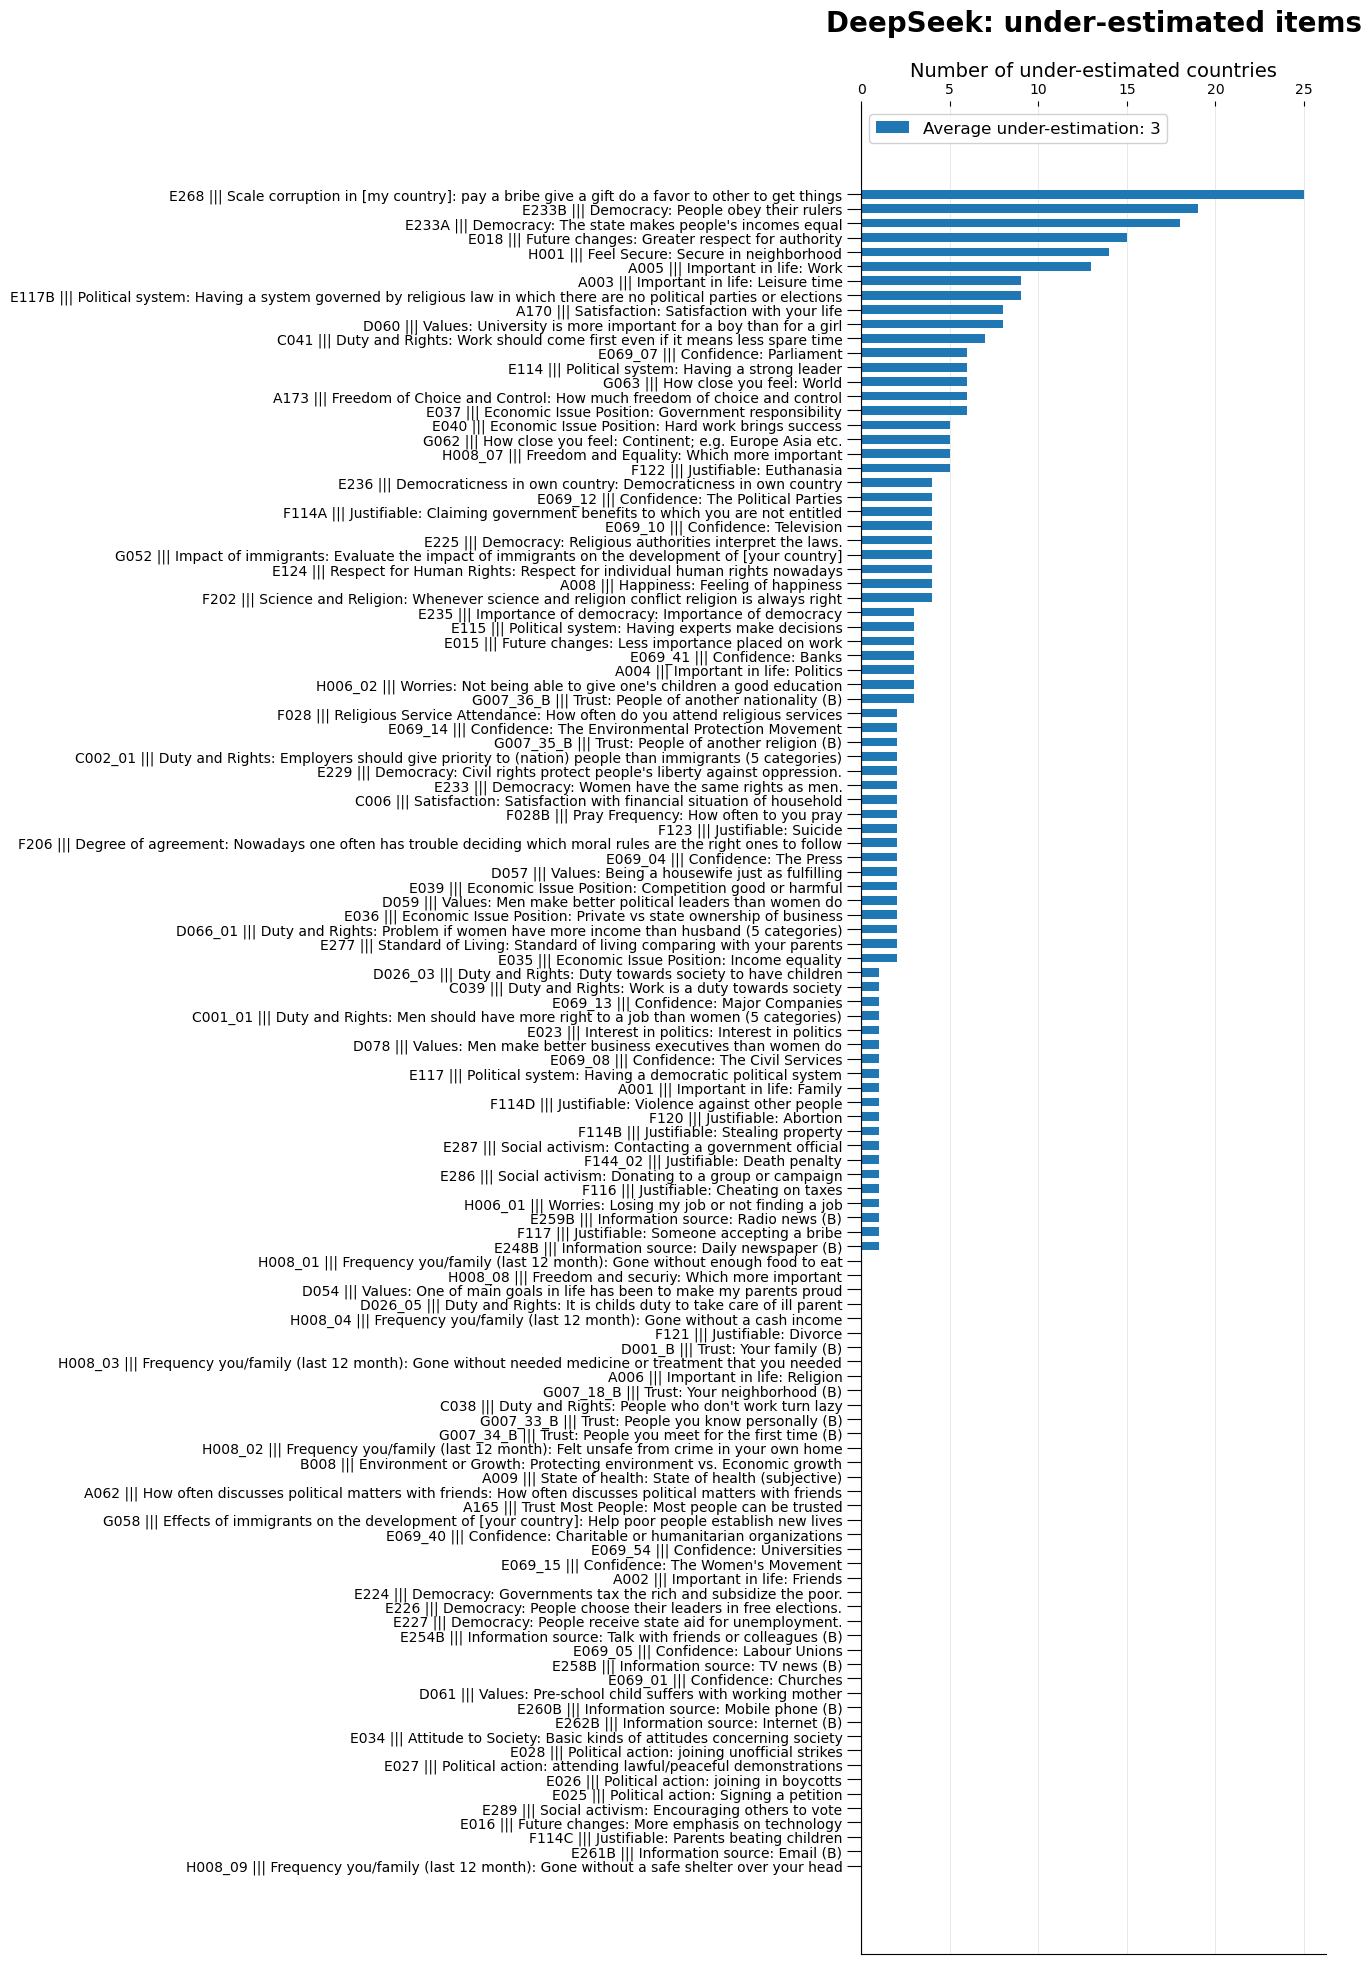

In [53]:
visualize_item_underrepresentation(df_error_byItem)

### Simulation test for error concentration 
- Test whether the errors are concentrated on specific items?
- Whether this happen by random or is significant?
    - Null hypothesis: given each country's observed number of errors, error locations across items are random.


In [ ]:
with open("./data/df_outlier_byIQR_gpt.pkl", "rb") as f:
    df_outlier_gpt = pickle.load(f)

with open("./data/df_outlier_byIQR_claude.pkl", "rb") as f:
    df_outlier_claude = pickle.load(f)

with open("./data/df_outlier_byIQR_deepseek.pkl", "rb") as f:
    df_outlier_deepseek = pickle.load(f)


In [ ]:
def run_simulation(df_outlier, llm_name, n_simulations=1000):

    # build the binary error matrix
    binary_error = (abs(df_outlier) != 0).astype(int)

    # count observed errors for each item
    observed_item_counts = binary_error.sum(axis=0)

    # choose a concentration statistic: how uneven the item errors are distributed across items
    observed_stat = np.var(observed_item_counts) # mean[(x-x_mean)^2]

    # record how many errors each country has
    errors_per_country = binary_error.sum(axis=1)

    # run simulation:
        # generate one null dataset
        # For each country, randomly choose the same number of items as its observed number of errors
        # Every item is equally likely to receive an error, conditional on the country's total number of errors

    n_countries, n_items = binary_error.shape

    null_stats = []

    for s in range(n_simulations):

        simulated = np.zeros((n_countries, n_items), dtype=int)

        for i in range(n_countries):

            k = int(errors_per_country.iloc[i]) # k error items for the ith country

            chosen_items = np.random.choice(
                n_items,
                size=k,
                replace=False
            )

            simulated[i, chosen_items] = 1

        # Calculate error_item counts for the simulated dataset
        simulated_item_counts = simulated.sum(axis=0)
        # break

        # variance of error_item counte
        simulated_stat = np.var(simulated_item_counts)

        null_stats.append(simulated_stat)

    # the amount of item-level concentration expected if no particular item were especially error-prone  
    null_stats = np.array(null_stats)

    return null_stats, observed_stat

In [23]:
gpt_null_stats, gpt_observed_stat = run_simulation(df_outlier_gpt, "GPT")

In [24]:
claude_null_stats, claude_observed_stat = run_simulation(df_outlier_claude, "Claude")

In [25]:
deepseek_null_stats, deepseek_observed_stat = run_simulation(df_outlier_deepseek, "DeepSeek")

In [26]:
# visualize the null distribution
# whether errors are more concentrated than expected by chance
def visualize_dist(null_stats, observed_stat, llm_name):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.hist(
        null_stats,
        bins=40,
        alpha=0.7
    )

    ax.axvline(
        observed_stat,
        linestyle='--',
        linewidth=2,
        label=f'llm_name observed = {observed_stat:.2f}'
    )

    ax.set_xlabel('Variance of item error counts')
    ax.set_ylabel('Number of simulations')
    ax.set_title(llm_name+': null distribution of error concentration')
    ax.legend()

    plt.show()

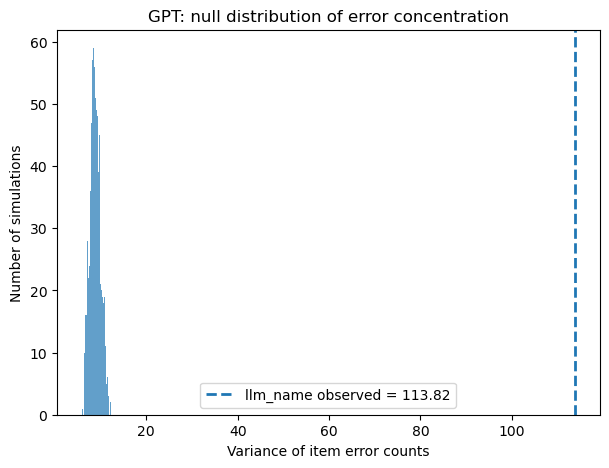

In [34]:
visualize_dist(gpt_null_stats, gpt_observed_stat,  "GPT")

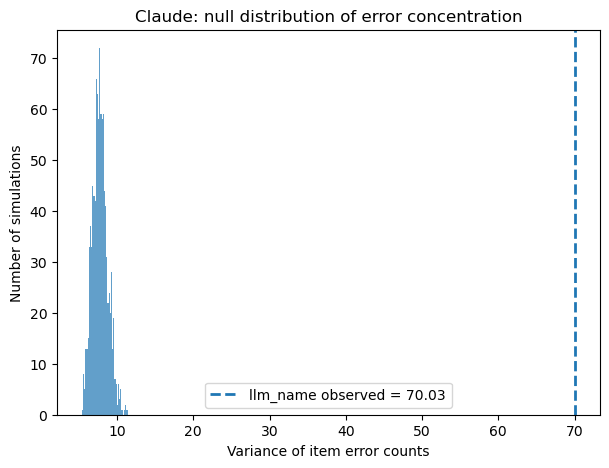

In [35]:
visualize_dist(claude_null_stats, claude_observed_stat,  "Claude")

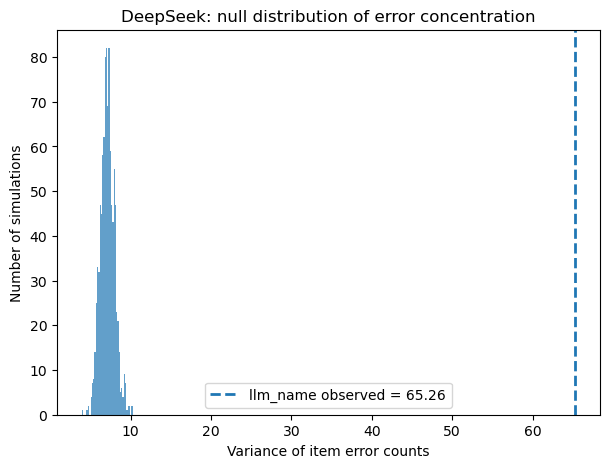

In [36]:
visualize_dist(deepseek_null_stats, deepseek_observed_stat,  "DeepSeek")

In [ ]:
# visualize the null distribution
# whether errors are more concentrated than expected by chance
def visualize_dist_combined(models_data):
    """
    models_data: list of (null_stats, observed_stat, llm_name) tuples
   """
    colors = ['steelblue', '#e67e22', '#239854']
    fig, ax = plt.subplots(figsize=(10, 5))

    for (null_stats, observed_stat, llm_name), color in zip(models_data, colors):
        ax.hist(null_stats, bins=40, alpha=0.4, color=color, label=f'{llm_name} null distribution')
        ax.axvline(observed_stat, linestyle='--', linewidth=2, color=color,
                   label=f'{llm_name} observed = {observed_stat:.2f}')

    ax.set_xlabel('Variance of item error counts', fontsize=15)
    ax.set_ylabel('#simulations', fontsize=15)
    ax.set_title('LLM error concentrations under null distributions', fontsize=16, fontweight='bold')
    legend_kwargs = dict(fontsize=9, loc='center left')
    # if legend_bbox is not None:
    legend_kwargs['bbox_to_anchor'] = (0.1, 0.8)
    ax.legend(**legend_kwargs)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    # fig.savefig("./supfig/simulation_test1.pdf", dpi=300, bbox_inches="tight")
    
    plt.show()

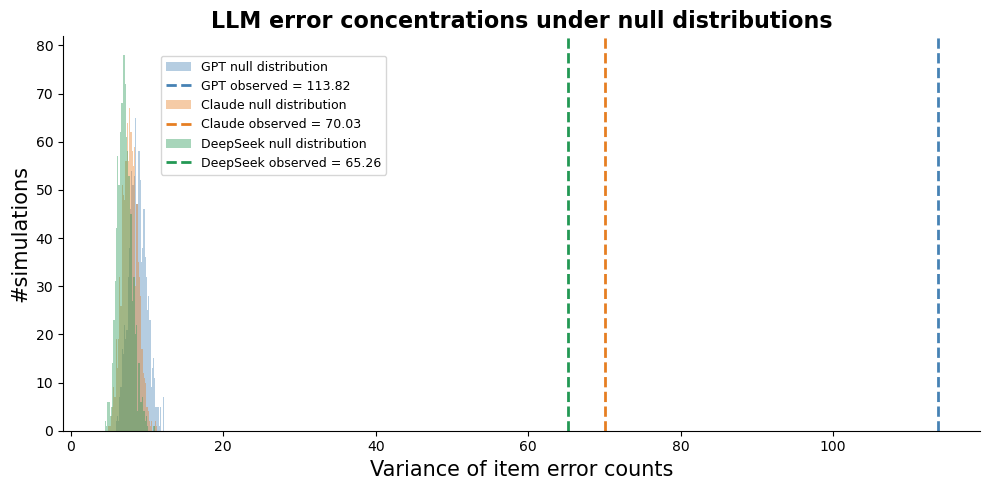

In [28]:
visualize_dist_combined([(gpt_null_stats, gpt_observed_stat,  "GPT"), 
                         (claude_null_stats, claude_observed_stat,  "Claude"),
                         (deepseek_null_stats, deepseek_observed_stat,  "DeepSeek")])

- Get one example of observed and simulated item counts from each case

In [29]:
def one_simulation_example(df_outlier):

    # build the binary error matrix
    binary_error = (abs(df_outlier) != 0).astype(int)

    # count observed errors for each item
    observed_item_counts = binary_error.sum(axis=0)

    # choose a concentration statistic: how uneven the item errors are distributed across items
    observed_stat = np.var(observed_item_counts) # mean[(x-x_mean)^2]

    # record how many errors each country has
    errors_per_country = binary_error.sum(axis=1)

    # count observed errors for each item
    observed_item_counts = binary_error.sum(axis=0)

    n_countries, n_items = binary_error.shape

    simulated = np.zeros((n_countries, n_items), dtype=int)

    for i in range(n_countries):

        k = int(errors_per_country.iloc[i]) # k error items for the ith country

        chosen_items = np.random.choice(
            n_items,
            size=k,
            replace=False
        )

        simulated[i, chosen_items] = 1

    # Calculate error_item counts for the simulated dataset
    simulated_item_counts = simulated.sum(axis=0)

    return observed_item_counts, simulated_item_counts

In [30]:
gpt_observed, gpt_simulated = one_simulation_example(df_outlier_gpt)
claude_observed, claude_simulated = one_simulation_example(df_outlier_claude)
deepseek_observed, deepseek_simulated = one_simulation_example(df_outlier_deepseek)

In [ ]:
def vis_one_simulation_example(models_data):
    """
    models_data: list of (observed_item_counts, simulated_item_counts, llm_name) tuples
    colors: steelblue=GPT, #e67e22=Claude, #2ecc71=DeepSeek
    """
    colors = ['steelblue', '#e67e22', '#239854']
    fig, ax = plt.subplots(figsize=(6, 5))

    for (observed, simulated, llm_name), color in zip(models_data, colors):
        ax.plot(sorted(observed), color=color, alpha=0.8, linewidth=1.5,
                label=f'{llm_name} observed')
        ax.plot(sorted(simulated), color=color, linewidth=2,
                linestyle=':', alpha=1, label=f'{llm_name} simulated')
        ax.yaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='--', zorder=0)
        ax.set_axisbelow(True)
        

    ax.set_ylabel('#Errors', fontsize=15)
    ax.set_xlabel('Survey items (sorted by #errors)', fontsize=15)
    ax.set_title('Simulated vs. observed item errors', fontsize=16, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9)
    plt.tight_layout()
#     fig.savefig("./supfig/simulation_test2.pdf", dpi=300, bbox_inches="tight")
    
    plt.show()

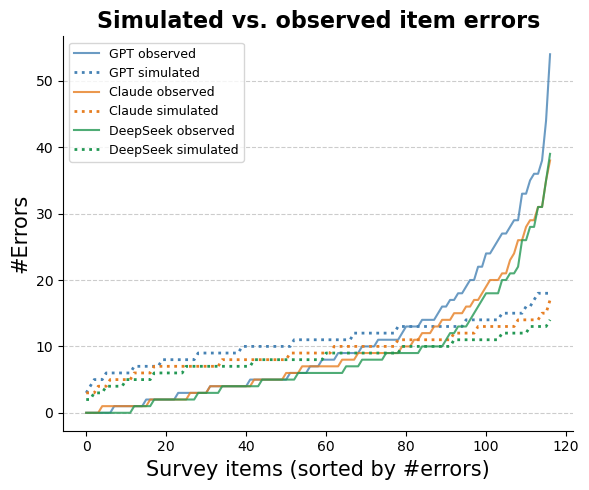

In [32]:
vis_one_simulation_example([(gpt_observed, gpt_simulated, "GPT"), 
                            (claude_observed, claude_simulated, "Claude"), 
                            (deepseek_observed, deepseek_simulated, "DeepSeek")])

In [ ]:
def vis_one_simulation_example_hstack(models_data):
    """
    models_data: list of (observed_item_counts, simulated_item_counts, llm_name) tuples
    Produces 3 vertically stacked subplots, one per model.
    suptitle_y: vertical position of the suptitle (figure fraction, default 0.98)
    """
    colors = ['steelblue', '#e67e22', "#239854"]
    fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True, sharey=True)

    for ax, (observed, simulated, llm_name), color in zip(axes, models_data, colors):
        ax.plot(sorted(observed), color=color, linewidth=1)
        ax.plot(sorted(simulated), color=color, linewidth=2, linestyle=':', alpha=0.7)
        ax.set_title(llm_name, fontsize=15, fontweight='bold', color=color, loc='left')
        ax.set_ylabel('#Errors', fontsize=15)
        ax.spines[['top', 'right']].set_visible(False)
        ax.yaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='--', zorder=0)
        ax.set_axisbelow(True)

    axes[-1].set_xlabel('117 Items (sorted)', fontsize=15)

    # shared legend with single color, placed below suptitle
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='gray', linewidth=1,        label='observed'),
        Line2D([0], [0], color='gray', linewidth=2, linestyle=':', label='simulated'),
    ]
    fig.legend(handles=legend_handles, fontsize=13, loc='upper center',
               bbox_to_anchor=(0.5, 0.88), ncol=2, frameon=False)

    fig.suptitle('Simulated vs. observed item error counts', fontsize=18,
                 fontweight='bold', y=0.9)
    plt.tight_layout()
    plt.subplots_adjust(top=0.8)
    # fig.savefig("./fig/7B_sim_2.pdf", dpi=300, bbox_inches="tight")
    plt.show()

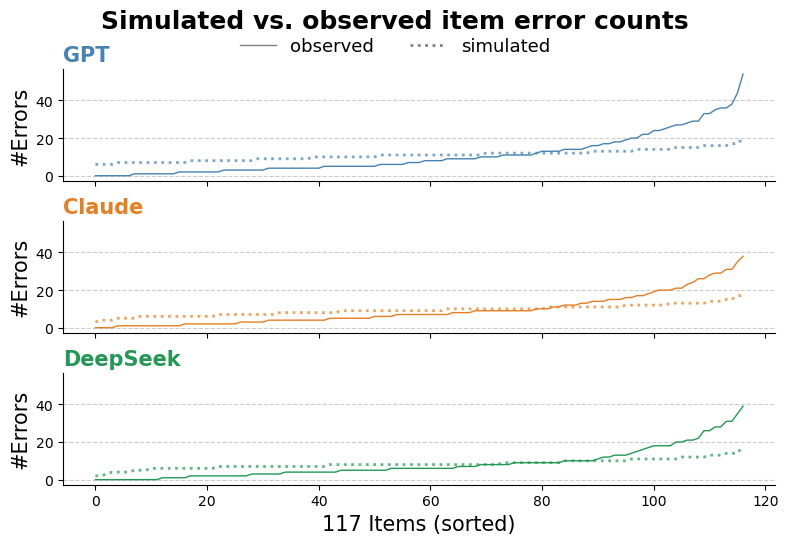

In [44]:
vis_one_simulation_example_hstack([(gpt_observed, gpt_simulated, "GPT"), 
                            (claude_observed, claude_simulated, "Claude"), 
                            (deepseek_observed, deepseek_simulated, "DeepSeek")])

-----------------------------The end-----------------------------